In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [5]:
class AgentState(TypedDict):
    num1 : int
    num2 : int
    operator : str
    result : int

In [9]:
def addition(state : AgentState) -> AgentState:
    state['result'] = state['num1'] + state['num2']
    return state
def subtraction(state : AgentState) -> AgentState:
    state['result'] = state['num1'] - state['num2']
    return state
def conditional_node(state : AgentState) -> AgentState:
    return state
def decider_function(state : AgentState) -> str:
    if state["operator"] == "+":
        return "addition_edge"
    else:
        return "subtraction_edge" 

In [11]:
graph = StateGraph(AgentState)
graph.add_node("add_node", addition)
graph.add_node("subtract_node", subtraction)
graph.add_node("conditional_node", conditional_node)

graph.set_entry_point("conditional_node")

graph.add_conditional_edges(
    "conditional_node",
    decider_function,
    {
        "addition_edge" : "add_node",
        "subtraction_edge" : "subtract_node"
    }
)

graph.set_finish_point("add_node")
graph.set_finish_point("subtract_node")
app = graph.compile()

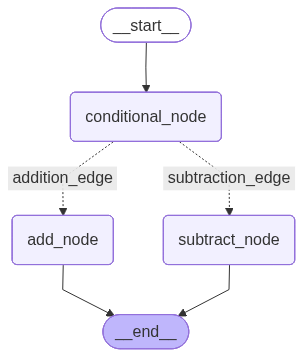

In [12]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [13]:
app.invoke({
    'num1' : 10,
    'num2' : 15,
    'operator' : '+'
})

{'num1': 10, 'num2': 15, 'operator': '+', 'result': 25}

### Graph 2

In [39]:
class AgentState(TypedDict):
    num1 : int
    num2 : int
    num3 : int
    operation1 : str
    operation2 : str
    result1 : int
    final_result : int

In [53]:
def addition(state : AgentState) -> AgentState:
    state['result1'] = state['num1'] + state['num2']
    return state
def subtraction(state : AgentState) -> AgentState:
    state['result1'] = state['num1'] - state['num2']
    return state
def division(state : AgentState) -> AgentState:
    state['final_result'] = state['result1'] / state['num3']
    return state
def multiplication(state : AgentState) -> AgentState:
    state['final_result'] = state['result1'] * state['num3']
    return state

In [54]:
def conditional_node1(state : AgentState) -> AgentState:
    return state

def decider_function1(state : AgentState) -> str:
    if (state['operation1'] == '+'):
        return "addition_edge"
    else:
        return "subtraction_edge"

In [55]:
def conditional_node2(state : AgentState) -> AgentState:
    return state

def decider_function2(state : AgentState) -> str:
    if (state['operation2'] == '*'):
        return "multiplication_edge"
    else:
        return "division_edge"

In [59]:
graph = StateGraph(AgentState)
graph.add_node("add_node", addition)
graph.add_node("subtract_node", subtraction)
graph.add_node("division_node", division)
graph.add_node("multiplication_node", multiplication)
graph.add_node("conditional_node1", conditional_node1)
graph.add_node("conditional_node2", conditional_node2)

graph.add_edge("add_node", "conditional_node2")
graph.add_edge("subtract_node", "conditional_node2")


graph.set_entry_point("conditional_node1")

graph.add_conditional_edges(
    "conditional_node1",
    decider_function1,
    {
        "addition_edge" : "add_node",
        "subtraction_edge" : "subtract_node"
    }
)

graph.add_conditional_edges(
    "conditional_node2",
    decider_function2,
    {
        "division_edge" : "division_node",
        "multiplication_edge" : "multiplication_node"
    }
)


graph.set_finish_point("division_node")
graph.set_finish_point("multiplication_node")
app = graph.compile()

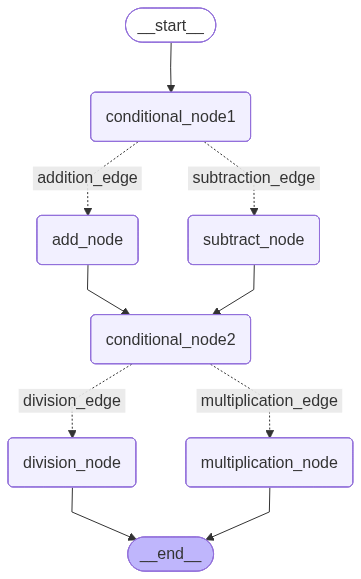

In [60]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [61]:
app.invoke({
    'num1' : 10,
    'num2' : 20,
    'operation1' : '+',
    'num3' : 5,
    'operation2' : '*'
})

{'num1': 10,
 'num2': 20,
 'num3': 5,
 'operation1': '+',
 'operation2': '*',
 'result1': 30,
 'final_result': 150}